# Normal Hopf

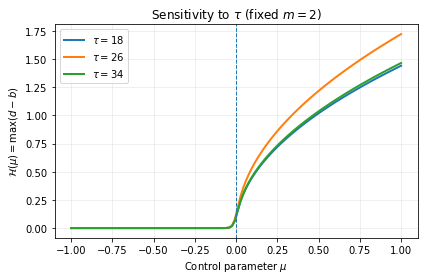

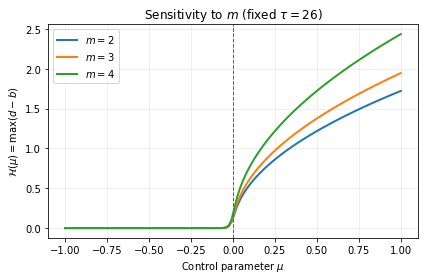

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from ripser import ripser

# ============================================================
# 1. SISTEMA HOPF NORMAL
# ============================================================

def hopf_normal(state, t, mu=0.0, omega=6.0):
    x, y = state
    r2 = x**2 + y**2
    dxdt = mu * x - omega * y - r2 * x
    dydt = omega * x + mu * y - r2 * y
    return np.array([dxdt, dydt])

def rk4_step(f, y, t, dt, **kwargs):
    k1 = f(y, t, **kwargs)
    k2 = f(y + dt/2 * k1, t + dt/2, **kwargs)
    k3 = f(y + dt/2 * k2, t + dt/2, **kwargs)
    k4 = f(y + dt * k3, t + dt, **kwargs)
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def simulate_hopf(mu, omega=6.0, y0=np.array([0.0, 1.01]), T=100, dt=0.01, sample_size=2000):
    t = np.arange(0, T, dt)
    Y = np.zeros((len(t), 2))
    Y[0] = y0
    for i in range(len(t)-1):
        Y[i+1] = rk4_step(hopf_normal, Y[i], t[i], dt, mu=mu, omega=omega)
    ts = Y[:, 0]
    return t[-sample_size:], ts[-sample_size:]

# ============================================================
# 2. FUNCIONAL MAX PERSISTENCE
# ============================================================

def max_persistence_from_ts(ts, tau, m, stride=2):
    embedder = SingleTakensEmbedding(
        parameters_type="fixed",
        time_delay=tau,
        dimension=m,
        stride=stride,
        n_jobs=1
    )
    X_emb = embedder.fit_transform(ts)
    dgms = ripser(X_emb, maxdim=1)["dgms"]
    H1 = dgms[1]

    # quitar infinitos si aparecen
    H1 = H1[np.isfinite(H1[:, 1])]
    if len(H1) == 0:
        return 0.0

    pers = H1[:, 1] - H1[:, 0]
    return np.max(pers)

# ============================================================
# 3. BARRIDO EN MU
# ============================================================

mu_values = np.linspace(-1, 1, 120)

def compute_curve(mu_values, tau, m, omega=6.0, stride=2):
    H_vals = []
    for mu in mu_values:
        _, ts = simulate_hopf(mu=mu, omega=omega)
        H = max_persistence_from_ts(ts, tau=tau, m=m, stride=stride)
        H_vals.append(H)
    return np.array(H_vals)

# ============================================================
# 4. SENSIBILIDAD EN TAU (m fijo)
# ============================================================

tau_list = [18, 26, 34]
m_fixed = 2

curves_tau = {}
for tau in tau_list:
    curves_tau[tau] = compute_curve(mu_values, tau=tau, m=m_fixed)

plt.figure(figsize=(6, 4))
for tau in tau_list:
    plt.plot(mu_values, curves_tau[tau], linewidth=2, label=fr"$\tau={tau}$")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel(r"Control parameter $\mu$")
plt.ylabel(r"$\mathcal{H}(\mu)=\max(d-b)$")
plt.title(r"Sensitivity to $\tau$ (fixed $m=2$)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("figure_hopf_tau_sensitivity.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 5. SENSIBILIDAD EN m (tau fijo)
# ============================================================

m_list = [2, 3, 4]
tau_fixed = 26

curves_m = {}
for m in m_list:
    curves_m[m] = compute_curve(mu_values, tau=tau_fixed, m=m)

plt.figure(figsize=(6, 4))
for m in m_list:
    plt.plot(mu_values, curves_m[m], linewidth=2, label=fr"$m={m}$")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel(r"Control parameter $\mu$")
plt.ylabel(r"$\mathcal{H}(\mu)=\max(d-b)$")
plt.title(r"Sensitivity to $m$ (fixed $\tau=26$)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("figure_hopf_m_sensitivity.pdf", dpi=300, bbox_inches="tight")
plt.show()

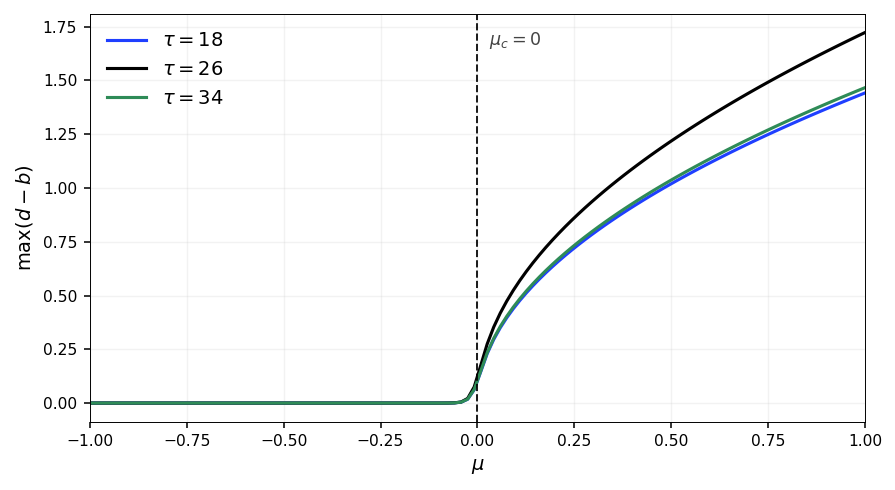

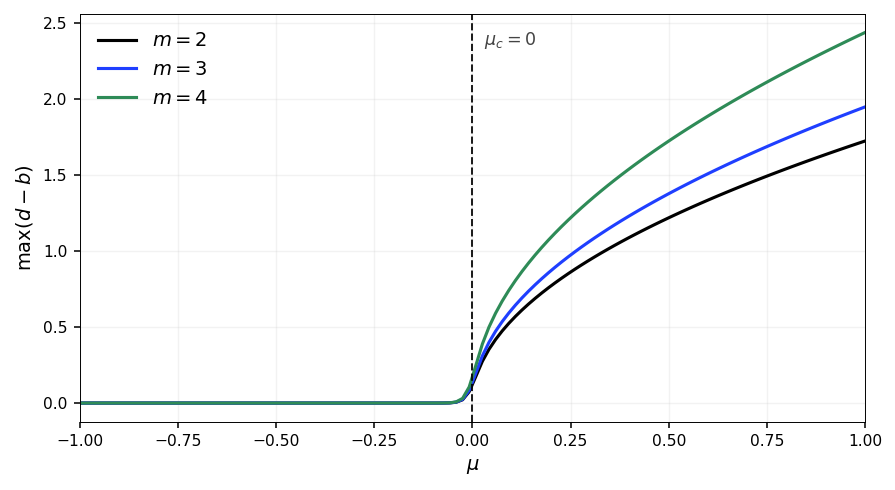

In [7]:
# ============================================================
# FIGURA 1 — Sensibilidad en tau (m fijo)
# ============================================================

TAU_COLORS = {
    18: "#1F3FFF",   # azul
    26: "#000000",   # negro (referencia)
    34: "#2E8B57"    # verde
}

fig, ax = plt.subplots(figsize=(6.5, 3.6))

for tau in sorted(curves_tau.keys()):
    ax.plot(
        mu_values,
        curves_tau[tau],
        color=TAU_COLORS[tau],
        lw=1.6,
        label=rf"$\tau={tau}$"
    )

ax.axvline(
    0.0,
    color=DIAG_COLOR,
    linestyle="--",
    linewidth=1.0,
    alpha=0.9
)

ax.text(
    0.03, 0.96,
    r"$\mu_c = 0$",
    transform=ax.get_xaxis_transform(),
    ha="left", va="top",
    fontsize=9,
    color="#444444"
)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\max(d-b)$")
ax.set_xlim(mu_values.min(), mu_values.max())
ax.set_xticks(np.arange(-1.0, 1.01, 0.25))
ax.margins(x=0.01)

style_2d_axes(ax)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.savefig("figure_hopf_tau_sensitivity.pdf", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# FIGURA 2 — Sensibilidad en m (tau fijo)
# ============================================================

M_COLORS = {
    2: "#000000",    # negro (referencia)
    3: "#1F3FFF",    # azul
    4: "#2E8B57"     # verde
}

fig, ax = plt.subplots(figsize=(6.5, 3.6))

for m in sorted(curves_m.keys()):
    ax.plot(
        mu_values,
        curves_m[m],
        color=M_COLORS[m],
        lw=1.6,
        label=rf"$m={m}$"
    )

ax.axvline(
    0.0,
    color=DIAG_COLOR,
    linestyle="--",
    linewidth=1.0,
    alpha=0.9
)

ax.text(
    0.03, 0.96,
    r"$\mu_c = 0$",
    transform=ax.get_xaxis_transform(),
    ha="left", va="top",
    fontsize=9,
    color="#444444"
)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\max(d-b)$")
ax.set_xlim(mu_values.min(), mu_values.max())
ax.set_xticks(np.arange(-1.0, 1.01, 0.25))
ax.margins(x=0.01)

style_2d_axes(ax)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.savefig("figure_hopf_m_sensitivity.pdf", dpi=300, bbox_inches="tight")
plt.show()